Title:
 Liver Disease Prediction using Machine Learning                                                                                   


Problem Statement:
 Liver disease cases are increasing due to alcohol consumption, harmful gases, contaminated food and drugs. This project aims to analyze patient health data and build machine learning models to predict whether a patient has liver disease or not.

Dataset contains 583 patient records:
1) 416 Liver patients
2) 167 Non-liver patients

In [69]:
#Import Required Libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 

#### Load Dataset

In [22]:
df = pd.read_csv("indian_liver_patient.csv")
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [6]:
df.shape

(582, 11)

#### Basic Data Exploration (EDA)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   65      582 non-null    int64  
 1   Female  582 non-null    object 
 2   0.7     582 non-null    float64
 3   0.1     582 non-null    float64
 4   187     582 non-null    int64  
 5   16      582 non-null    int64  
 6   18      582 non-null    int64  
 7   6.8     582 non-null    float64
 8   3.3     582 non-null    float64
 9   0.9     578 non-null    float64
 10  1       582 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.1+ KB


In [10]:
df.describe()

,65,0.7,0.1,187,16,18,6.8,3.3,0.9,1
count,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,578.000000,582.000000
mean,44.711340,3.303265,1.488488,290.754296,80.824742,110.068729,6.482646,3.141581,0.947145,1.286942
std,16.181921,6.213926,2.810324,243.108929,182.757696,289.141876,1.086306,0.796176,0.319863,0.452723
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.250000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.940000,1.000000
75%,57.750000,2.600000,1.300000,298.000000,60.750000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [12]:
df.isnull().sum()

65        0
Female    0
0.7       0
0.1       0
187       0
16        0
18        0
6.8       0
3.3       0
0.9       4
1         0
dtype: int64

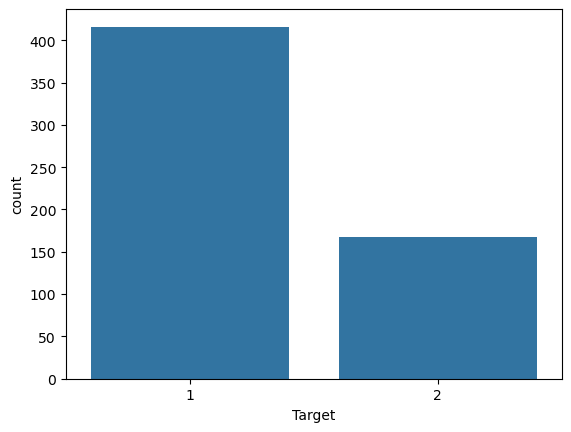

In [24]:
sns.countplot(x='Target', data=df)
plt.show()

#### Data Cleaning

In [28]:
#Handle Missing Values
df['Albumin_and_Globulin_Ratio'] = df['Albumin_and_Globulin_Ratio'].fillna(df['Albumin_and_Globulin_Ratio'].mean())

In [30]:
#Convert Gender to Numeric
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

#### Exploratory Data Analysis (Visualization)

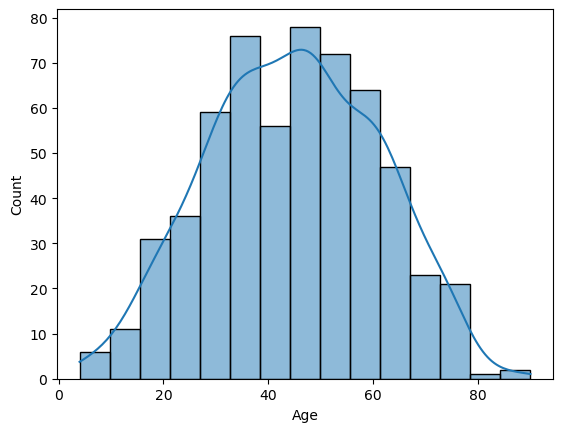

In [32]:
#Age Distribution
sns.histplot(df['Age'], kde=True)
plt.show()

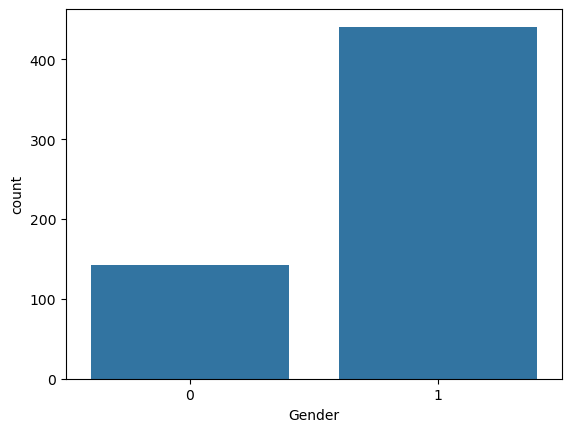

In [34]:
#Gender Distribution
sns.countplot(x='Gender', data=df)
plt.show()

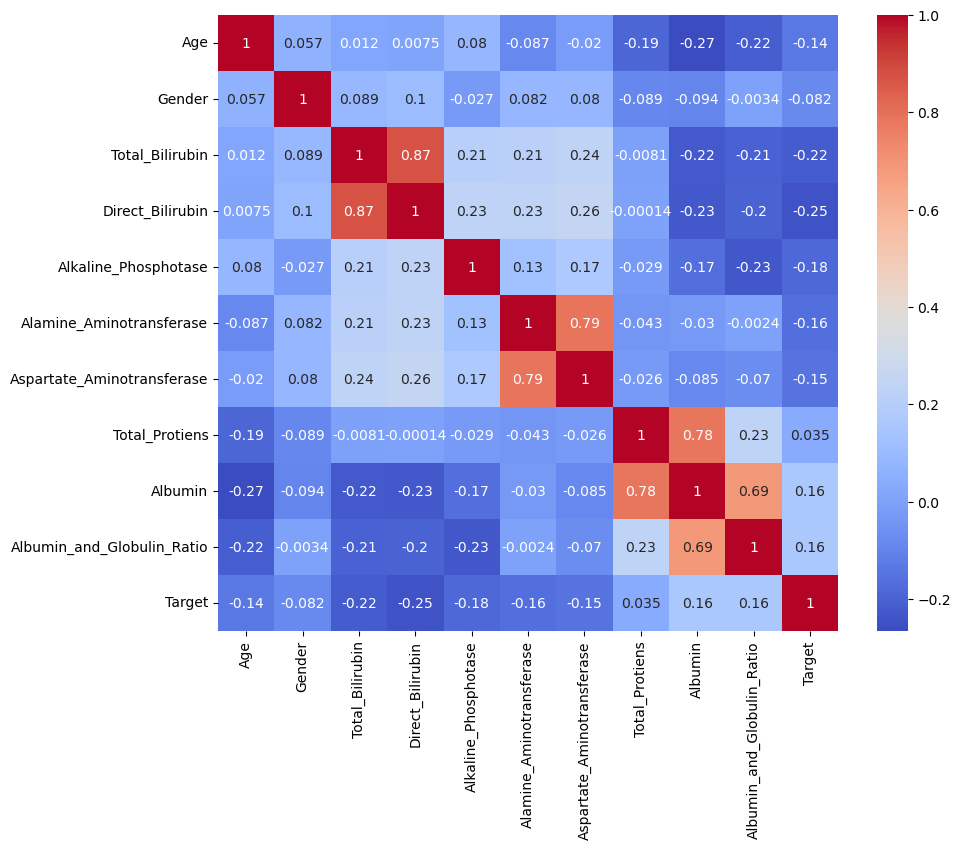

In [36]:
# Correlation HeatMap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

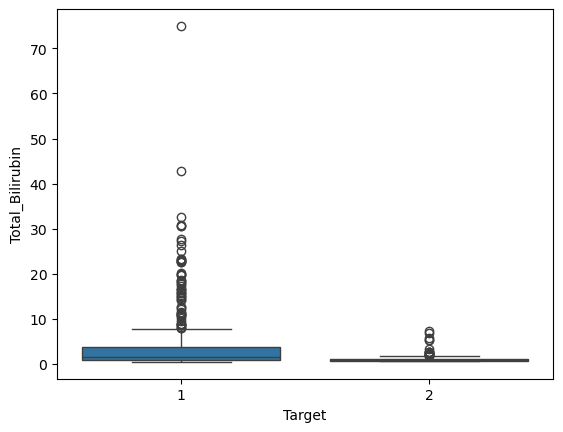

In [75]:
#Feature vs Target
sns.boxplot(x='Target', y='Total_Bilirubin', data=df)
plt.show()

#### Feature Selection

In [38]:
#Separate X (features) and y (target)
X = df.drop('Target', axis=1)
y = df['Target']

Train Test Split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Feature Scalling

In [42]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Model Building (Different Classifiers)

In [44]:
#Logistic Regression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7606837606837606
[[80  7]
 [21  9]]
              precision    recall  f1-score   support

           1       0.79      0.92      0.85        87
           2       0.56      0.30      0.39        30

    accuracy                           0.76       117
   macro avg       0.68      0.61      0.62       117
weighted avg       0.73      0.76      0.73       117



In [46]:
#Decision Tree

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.7094017094017094


In [48]:
#Random Forest

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.7521367521367521


In [50]:
#Support Vector Machine

svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))

Accuracy: 0.7435897435897436


In [52]:
#K-Nearest Neighbors

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))

Accuracy: 0.6666666666666666


#### Model Comparison Report

In [54]:
results = pd.DataFrame({
    'Model': ['Logistic Regression','Decision Tree','Random Forest','SVM','KNN'],
    'Accuracy': [
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_svm),
        accuracy_score(y_test,y_pred_knn)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.760684
1,Decision Tree,0.709402
2,Random Forest,0.752137
3,SVM,0.743590
4,KNN,0.666667


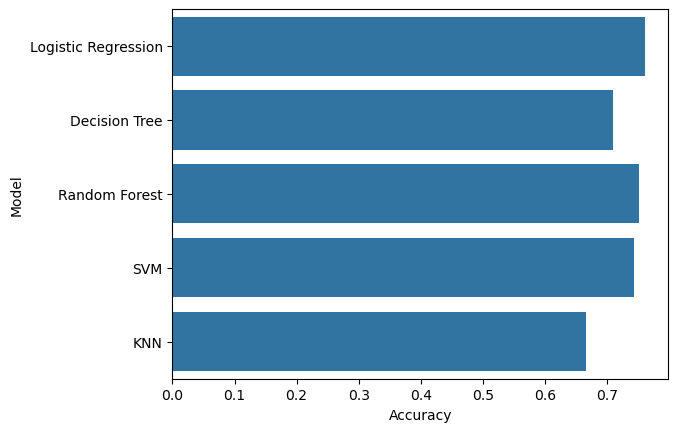

In [56]:
sns.barplot(x='Accuracy', y='Model', data=results)
plt.show()

Random Forest achieved the highest accuracy compared to other models. Hence it is selected as the final model for liver disease prediction.

#### Model Design Explanation

why features were selected and why Random Forest works best?


Explanation:

* Dataset contains medical parameters related to liver function.

* Features like Bilirubin, Albumin, Enzyme levels are strong indicators of liver disease.

* Random Forest performs well because:

1) Handles nonlinear relationships

2) Works well with medical datasets

3) Reduces overfitting


#### Challenges Faced

1) Missing values in Albumin and Globulin Ratio
→ Solved using Mean Imputation

2) Categorical variable (Gender)
→ Converted using Label Encoding

3) Feature scaling required
→ Applied StandardScaler

4) Class imbalance in dataset
→ Evaluated using multiple models

#### Final Conclusion

* Data analysis helped understand liver health indicators.

* Multiple models were trained and evaluated.

* Random Forest gave the best performance.

* Model can assist doctors in early detection of liver disease.